In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append('../')

from minilearn.regression import LinearRegression as MinilearnLR
from sklearn.linear_model import LinearRegression as SklearnLR
from sklearn.metrics import mean_squared_error, r2_score

train_df = pd.read_csv('../data/train_features.csv')
test_df = pd.read_csv('../data/test_features.csv')

features_df = pd.read_csv('../data/features.csv')
features_df = features_df.copy() #fixes performance issues

features_df['intensity_encoded'] = features_df['intensity'].map({'normal':0, 'strong': 1})

features_df = features_df[features_df['emotion'] != 'neutral']
print(features_df['intensity_encoded'].value_counts())
print(f"remaining samples: {len(features_df)}")


intensity_encoded
0    1132
1    1132
Name: count, dtype: int64
remaining samples: 2264


In [2]:
#get feature Columns
metadata_cols = ['filename', 'emotion', 'vocal_channel', 'intensity', 'actor', 'gender', 'intensity_encoded']
feature_cols = [col for col in  features_df.columns if col not in metadata_cols]

X = features_df[feature_cols].values
y = features_df['intensity_encoded'].values

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42, stratify=y)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

Training set: (1811, 112)
Test set: (453, 112)


In [5]:
#import standard scaler

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

minilearn_model = MinilearnLR(learning_rate=0.01, n_iteration=1000)
minilearn_model.fit(X_train_scaled, y_train)

sklearn_model = SklearnLR()
sklearn_model.fit(X_train_scaled, y_train)

mini_preds = minilearn_model.predict(X_test_scaled)
sklearn_preds = sklearn_model.predict(X_test_scaled)

#Evaluation of mean squared error and R2 score
print("MiniLearn Linear Regression")
print(f"MSE: {mean_squared_error(y_test, mini_preds):.4f}")
print(f"R2 Score: {r2_score(y_test, mini_preds):.4f}")

print("\n Sklearn Linear Regression")
print(f"MSE: {mean_squared_error(y_test, sklearn_preds):.4f}")
print(f"R2 Score: {r2_score(y_test, sklearn_preds):.4f}")
print("Explaination: my minilearn is working as intended if not slightly better than the Sklearn linear regressor. \n The lower the mean squared error is the better. the R2 score is lowe because a linear regressor isnt the best tool to use for Intensity,\n a classifer would be better.")


MiniLearn Linear Regression
MSE: 0.2080
R2 Score: 0.1681

 Sklearn Linear Regression
MSE: 0.2111
R2 Score: 0.1557
Explaination: my minilearn is working as intended if not slightly better than the Sklearn linear regressor. 
 The lower the mean squared error is the better. the R2 score is lowe because a linear regressor isnt the best tool to use for Intensity,
 a classifer would be better.


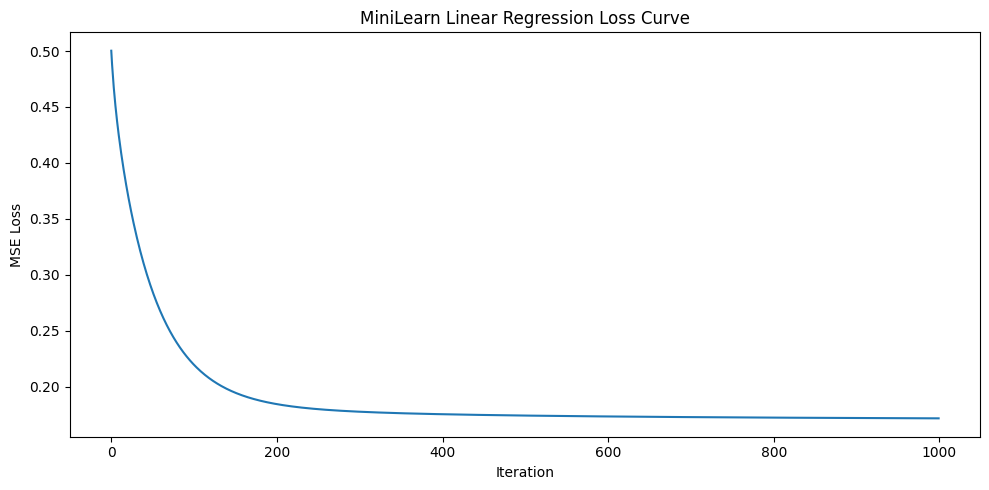

Plot to represent the mean squared error loss in relation to the iteration, (exponential decrease)


In [7]:
plt.figure(figsize=(10,5))
plt.plot(minilearn_model.loss_history)
plt.title("MiniLearn Linear Regression Loss Curve")
plt.xlabel("Iteration")
plt.ylabel("MSE Loss")
plt.tight_layout()
plt.show()
print("Plot to represent the mean squared error loss in relation to the iteration, (exponential decrease)")

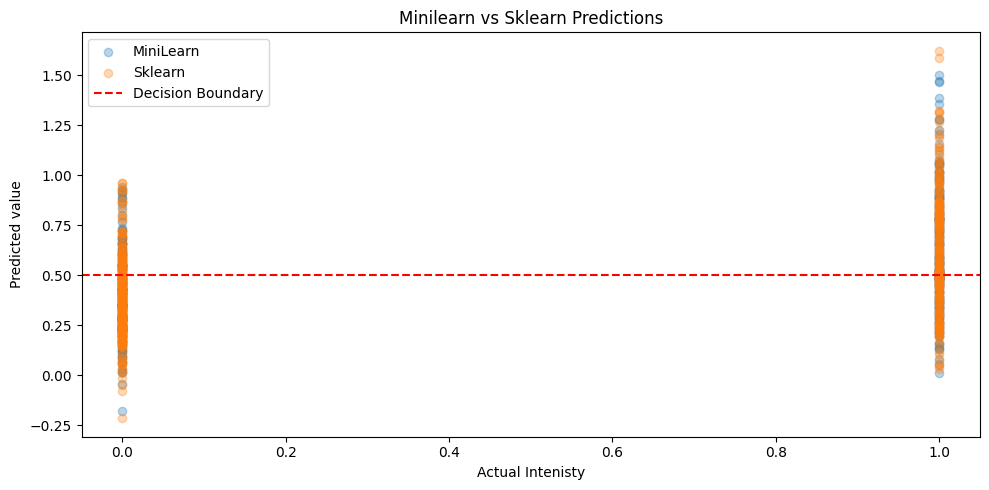

In [8]:
# Compare my Predictions
plt.figure(figsize=(10,5))
plt.scatter(y_test, mini_preds, alpha=0.3, label="MiniLearn")
plt.scatter(y_test, sklearn_preds, alpha=0.3, label="Sklearn")
plt.axhline(y=0.5, color='r', linestyle='--', label='Decision Boundary')
plt.xlabel("Actual Intenisty")
plt.ylabel("Predicted value")
plt.title("Minilearn vs Sklearn Predictions")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
## Analysis
# We used linear regression to predict the emotional intensity (Normal: 0 or Strong: 1) from the audio feature
# both minilearn and sklearn gave me similar results but R2 scores ending up around 0.16 and the Mean Squared Error ending around 0.2
# my Minilearn preformed slightly better when it came to  mean sqaure error calculation. 
# the very low R2 scores indicate that linear regression isnt the best model for a variable like Intensity
# Since Intensity is binary Linear Regression has limited application as you can see in the graph above 
# linear regression thrives whne the variable is continuous not binary. 
